In [1]:
import pandas as pd
import os

In [2]:
PATH = r'c:\Users\Admin\Documents\GitHub\plum_sid_coursework\experiments\tables'
l3_res = pd.read_csv(os.path.join(PATH, 'tiebreak_result_l3.csv'))
l4_res = pd.read_csv(os.path.join(PATH, 'tiebreak_result_l4.csv'), index_col=0)
l3_res.head()

,train_seed,tiebreak,vocab,max_dupe,unique_sids,collapsed,Recall@1,Recall@5,Recall@10,Recall@20,NDCG@1,NDCG@5,NDCG@10,NDCG@20,val_loss_best
0,0,base_only,770,0,10700,1401,0.0072,0.0268,0.0462,0.0774,0.0072,0.0171,0.0232,0.0311,1.6509
1,0,count,784,14,12101,0,0.0068,0.0269,0.0482,0.0821,0.0068,0.0169,0.0237,0.0322,1.3487
2,0,centroid,784,14,12101,0,0.0079,0.0292,0.0487,0.0827,0.0079,0.0185,0.0247,0.0333,1.3341
3,0,popularity,784,14,12101,0,0.0072,0.0285,0.0486,0.0808,0.0072,0.0179,0.0243,0.0324,1.3437
4,0,semantic_strict,790,20,12101,0,0.0076,0.0280,0.0486,0.0814,0.0076,0.0176,0.0242,0.0324,1.3085


In [3]:
l4_res.head()

,train_seed,tiebreak,vocab,max_dupe,unique_sids,collapsed,Recall@1,Recall@5,Recall@10,Recall@20,NDCG@1,NDCG@5,NDCG@10,NDCG@20,val_loss_best,n_layers
0,0,base_only,1026,0,11754,347,0.0077,0.0277,0.0522,0.0881,0.0077,0.0177,0.0255,0.0346,1.2903,4
1,0,count,1032,6,12101,0,0.0062,0.0252,0.0474,0.0839,0.0062,0.0153,0.0225,0.0317,1.0993,4
2,0,centroid,1032,6,12101,0,0.0069,0.0253,0.0470,0.0851,0.0069,0.0159,0.0229,0.0324,1.1010,4
3,0,popularity,1032,6,12101,0,0.0061,0.0257,0.0475,0.0861,0.0061,0.0159,0.0229,0.0326,1.1002,4
4,0,semantic_strict,1037,11,12101,0,0.0070,0.0258,0.0480,0.0858,0.0070,0.0163,0.0234,0.0329,1.1004,4


In [4]:
l3_res['n_layers'] = 3
l4_res['n_layers'] = 4
res = pd.concat([l3_res, l4_res])
rec_sys_cols = [col for col in res if col.startswith('Recall') or col.startswith('NDCG')]
res.head()

,train_seed,tiebreak,vocab,max_dupe,unique_sids,collapsed,Recall@1,Recall@5,Recall@10,Recall@20,NDCG@1,NDCG@5,NDCG@10,NDCG@20,val_loss_best,n_layers
0,0,base_only,770,0,10700,1401,0.0072,0.0268,0.0462,0.0774,0.0072,0.0171,0.0232,0.0311,1.6509,3
1,0,count,784,14,12101,0,0.0068,0.0269,0.0482,0.0821,0.0068,0.0169,0.0237,0.0322,1.3487,3
2,0,centroid,784,14,12101,0,0.0079,0.0292,0.0487,0.0827,0.0079,0.0185,0.0247,0.0333,1.3341,3
3,0,popularity,784,14,12101,0,0.0072,0.0285,0.0486,0.0808,0.0072,0.0179,0.0243,0.0324,1.3437,3
4,0,semantic_strict,790,20,12101,0,0.0076,0.0280,0.0486,0.0814,0.0076,0.0176,0.0242,0.0324,1.3085,3


In [5]:
rec_sys_cols

['Recall@1',
 'Recall@5',
 'Recall@10',
 'Recall@20',
 'NDCG@1',
 'NDCG@5',
 'NDCG@10',
 'NDCG@20']

In [6]:
res.head()

,train_seed,tiebreak,vocab,max_dupe,unique_sids,collapsed,Recall@1,Recall@5,Recall@10,Recall@20,NDCG@1,NDCG@5,NDCG@10,NDCG@20,val_loss_best,n_layers
0,0,base_only,770,0,10700,1401,0.0072,0.0268,0.0462,0.0774,0.0072,0.0171,0.0232,0.0311,1.6509,3
1,0,count,784,14,12101,0,0.0068,0.0269,0.0482,0.0821,0.0068,0.0169,0.0237,0.0322,1.3487,3
2,0,centroid,784,14,12101,0,0.0079,0.0292,0.0487,0.0827,0.0079,0.0185,0.0247,0.0333,1.3341,3
3,0,popularity,784,14,12101,0,0.0072,0.0285,0.0486,0.0808,0.0072,0.0179,0.0243,0.0324,1.3437,3
4,0,semantic_strict,790,20,12101,0,0.0076,0.0280,0.0486,0.0814,0.0076,0.0176,0.0242,0.0324,1.3085,3


In [7]:
stats_grouped = res.groupby(['tiebreak', 'n_layers'])[rec_sys_cols].agg(['mean', 'std'])
stats_df = pd.DataFrame(index=stats_grouped.index)
for metric in rec_sys_cols:
    stats_df[metric] = (
        stats_grouped[(metric, 'mean')].map(lambda x: f'{x:.5f}')
        + ' +/- '
        + stats_grouped[(metric, 'std')].map(lambda x: f'{x:.5f}')
    )
stats_df.T

tiebreak             base_only                                  centroid  \
n_layers                     3                    4                    3   
Recall@1   0.00758 +/- 0.00063  0.00660 +/- 0.00080  0.00728 +/- 0.00049   
Recall@5   0.02824 +/- 0.00088  0.02686 +/- 0.00081  0.02764 +/- 0.00131   
Recall@10  0.04738 +/- 0.00079  0.04964 +/- 0.00176  0.04830 +/- 0.00142   
Recall@20  0.07858 +/- 0.00138  0.08624 +/- 0.00179  0.08098 +/- 0.00132   
NDCG@1     0.00758 +/- 0.00063  0.00660 +/- 0.00080  0.00728 +/- 0.00049   
NDCG@5     0.01780 +/- 0.00058  0.01656 +/- 0.00067  0.01730 +/- 0.00096   
NDCG@10    0.02392 +/- 0.00053  0.02382 +/- 0.00097  0.02390 +/- 0.00085   
NDCG@20    0.03178 +/- 0.00063  0.03304 +/- 0.00094  0.03210 +/- 0.00087   

tiebreak                                      count                       \
n_layers                     4                    3                    4   
Recall@1   0.00640 +/- 0.00067  0.00718 +/- 0.00031  0.00634 +/- 0.00035   
Recall@5   0.02582 +/- 0.00116  0.02704 +/- 0.00028  0.02486 +/- 0.00220   
Recall@10  0.04622 +/- 0.00082  0.04814 +/- 0.00112  0.04608 +/- 0.00225   
Recall@20  0.08300 +/- 0.00139  0.08168 +/- 0.00140  0.08274 +/- 0.00208   
NDCG@1     0.00640 +/- 0.00067  0.00718 +/- 0.00031  0.00634 +/- 0.00035   
NDCG@5     0.01600 +/- 0.00070  0.01700 +/- 0.00022  0.01542 +/- 0.00122   
NDCG@10    0.02254 +/- 0.00060  0.02376 +/- 0.00049  0.02220 +/- 0.00115   
NDCG@20    0.03178 +/- 0.00055  0.03216 +/- 0.00055  0.03144 +/- 0.00097   

tiebreak            popularity                           semantic_strict  \
n_layers                     3                    4                    3   
Recall@1   0.00712 +/- 0.00022  0.00658 +/- 0.00057  0.00712 +/- 0.00054   
Recall@5   0.02688 +/- 0.00120  0.02524 +/- 0.00078  0.02836 +/- 0.00032   
Recall@10  0.04812 +/- 0.00096  0.04660 +/- 0.00161  0.04942 +/- 0.00056   
Recall@20  0.08086 +/- 0.00043  0.08380 +/- 0.00236  0.08352 +/- 0.00170   
NDCG@1     0.00712 +/- 0.00022  0.00658 +/- 0.00057  0.00712 +/- 0.00054   
NDCG@5     0.01696 +/- 0.00080  0.01580 +/- 0.00062  0.01764 +/- 0.00036   
NDCG@10    0.02376 +/- 0.00058  0.02264 +/- 0.00081  0.02438 +/- 0.00044   
NDCG@20    0.03200 +/- 0.00050  0.03196 +/- 0.00107  0.03294 +/- 0.00070   

tiebreak                        
n_layers                     4  
Recall@1   0.00648 +/- 0.00043  
Recall@5   0.02648 +/- 0.00078  
Recall@10  0.04754 +/- 0.00040  
Recall@20  0.08376 +/- 0.00222  
NDCG@1     0.00648 +/- 0.00043  
NDCG@5     0.01642 +/- 0.00045  
NDCG@10    0.02316 +/- 0.00035  
NDCG@20    0.03226 +/- 0.00074

In [8]:
all_metrics = rec_sys_cols + ['val_loss_best']

mean_scores = res.groupby(['n_layers', 'tiebreak'])[all_metrics].mean()
best_rows = []
for n_layers in sorted(res['n_layers'].unique()):
    layer_scores = mean_scores.loc[n_layers]
    for metric in all_metrics:
        best_tiebreak = layer_scores[metric].idxmin() if metric == 'val_loss_best' else layer_scores[metric].idxmax()
        best_rows.append({
            'n_layers': n_layers,
            'metric': metric,
            'best_tiebreak': best_tiebreak,
            'best_mean': layer_scores.loc[best_tiebreak, metric],
        })

best_by_mean = pd.DataFrame(best_rows)
best_by_mean.pivot(index='metric', columns='n_layers', values='best_tiebreak')

n_layers,3,4
metric,,
NDCG@1,base_only,base_only
NDCG@10,semantic_strict,base_only
NDCG@20,semantic_strict,base_only
NDCG@5,base_only,base_only
Recall@1,base_only,base_only
Recall@10,semantic_strict,base_only
Recall@20,semantic_strict,base_only
Recall@5,semantic_strict,base_only
val_loss_best,semantic_strict,semantic_strict


In [9]:
best_by_mean

,n_layers,metric,best_tiebreak,best_mean
0,3,Recall@1,base_only,0.00758
1,3,Recall@5,semantic_strict,0.02836
2,3,Recall@10,semantic_strict,0.04942
3,3,Recall@20,semantic_strict,0.08352
4,3,NDCG@1,base_only,0.00758
5,3,NDCG@5,base_only,0.01780
6,3,NDCG@10,semantic_strict,0.02438
7,3,NDCG@20,semantic_strict,0.03294
8,3,val_loss_best,semantic_strict,1.30784
9,4,Recall@1,base_only,0.00660


In [10]:
def paired_deltas(df, baseline, metrics=('Recall@20', 'NDCG@20', 'val_loss_best')):
    rows = []

    for n_layers, layer_df in df.groupby('n_layers'):
        base = layer_df[layer_df['tiebreak'] == baseline].set_index('train_seed')

        for tiebreak in sorted(layer_df['tiebreak'].unique()):
            if tiebreak == baseline:
                continue

            candidate = layer_df[layer_df['tiebreak'] == tiebreak].set_index('train_seed')
            common_seeds = sorted(set(base.index) & set(candidate.index))

            row = {
                'n_layers': n_layers,
                'baseline': baseline,
                'tiebreak': tiebreak,
                'n_seeds': len(common_seeds),
            }

            for metric in metrics:
                base_values = base.loc[common_seeds, metric]
                candidate_values = candidate.loc[common_seeds, metric]

                delta = candidate_values - base_values

                # Relative change vs baseline, in %
                delta_pct = delta / base_values.abs().where(base_values != 0) * 100

                # Improvement %, where positive always means better
                if metric == 'val_loss_best':
                    improvement_pct = -delta_pct
                    better = delta < 0
                else:
                    improvement_pct = delta_pct
                    better = delta > 0

                row[f'{metric}_delta_mean'] = delta.mean()
                row[f'{metric}_delta_std'] = delta.std(ddof=1)

                row[f'{metric}_delta_pct_mean'] = delta_pct.mean()
                row[f'{metric}_delta_pct_std'] = delta_pct.std(ddof=1)

                row[f'{metric}_improvement_pct_mean'] = improvement_pct.mean()
                row[f'{metric}_wins'] = int(better.sum())

            rows.append(row)

    return pd.DataFrame(rows)

deltas_vs_count = paired_deltas(res, 'count')

cols = [
    'n_layers', 'tiebreak', 'n_seeds',
    'Recall@20_delta_mean', 'Recall@20_improvement_pct_mean', 'Recall@20_wins',
    'NDCG@20_delta_mean', 'NDCG@20_improvement_pct_mean', 'NDCG@20_wins',
    'val_loss_best_delta_mean', 'val_loss_best_improvement_pct_mean', 'val_loss_best_wins',
]

deltas_vs_count[cols]

,n_layers,tiebreak,n_seeds,Recall@20_delta_mean,Recall@20_improvement_pct_mean,Recall@20_wins,NDCG@20_delta_mean,NDCG@20_improvement_pct_mean,NDCG@20_wins,val_loss_best_delta_mean,val_loss_best_improvement_pct_mean,val_loss_best_wins
0,3,base_only,5,-0.00310,-3.766008,0,-0.00038,-1.150466,1,0.30384,-22.691065,0
1,3,centroid,5,-0.00070,-0.826266,2,-0.00006,-0.158745,2,-0.00358,0.265947,2
2,3,popularity,5,-0.00082,-0.985535,1,-0.00016,-0.469414,2,0.00112,-0.084192,3
3,3,semantic_strict,5,0.00184,2.293451,3,0.00078,2.474651,4,-0.03120,2.328352,5
4,4,base_only,5,0.00350,4.243134,5,0.00160,5.143201,5,0.19204,-17.325359,0
5,4,centroid,5,0.00026,0.342326,4,0.00034,1.133354,4,0.00274,-0.246250,1
6,4,popularity,5,0.00106,1.290037,3,0.00052,1.662812,4,0.00240,-0.216425,1
7,4,semantic_strict,5,0.00102,1.315275,4,0.00082,2.724906,4,-0.00534,0.477664,3


In [11]:
winner_rows = []

for n_layers, layer_df in res.groupby('n_layers'):
    n_seeds = layer_df['train_seed'].nunique()

    for metric in all_metrics:
        for train_seed, seed_df in layer_df.groupby('train_seed'):
            best_value = seed_df[metric].min() if metric == 'val_loss_best' else seed_df[metric].max()
            winners = seed_df.loc[seed_df[metric] == best_value, 'tiebreak'].unique()
            win_weight = 1 / len(winners)

            for tiebreak in winners:
                winner_rows.append({
                    'n_layers': n_layers,
                    'metric': metric,
                    'tiebreak': tiebreak,
                    'win': win_weight,
                    'n_seeds': n_seeds,
                })

winner_freq = (
    pd.DataFrame(winner_rows)
    .groupby(['n_layers', 'metric', 'tiebreak'], as_index=False)
    .agg(
        wins=('win', 'sum'),
        n_seeds=('n_seeds', 'first'),
    )
)

winner_freq['win_rate_pct'] = 100 * winner_freq['wins'] / winner_freq['n_seeds']

display(
    winner_freq.pivot_table(
        index=['metric', 'tiebreak'],
        columns='n_layers',
        values='win_rate_pct',
        fill_value=0,
    ).round(1)
)

n_layers                           3      4
metric        tiebreak                     
NDCG@1        base_only         40.0   20.0
              centroid          40.0   20.0
              count             20.0    0.0
              popularity         0.0   40.0
              semantic_strict    0.0   20.0
NDCG@10       base_only         10.0   66.7
              centroid          40.0    6.7
              count             20.0    0.0
              semantic_strict   30.0   26.7
NDCG@20       base_only          0.0   60.0
              centroid          20.0    0.0
              count             20.0    0.0
              popularity         0.0   20.0
              semantic_strict   60.0   20.0
NDCG@5        base_only         60.0   20.0
              centroid          40.0   40.0
              count              0.0   10.0
              popularity         0.0   10.0
              semantic_strict    0.0   20.0
Recall@1      base_only         40.0   20.0
              centroid          40.0   20.0
              count             20.0    0.0
              popularity         0.0   40.0
              semantic_strict    0.0   20.0
Recall@10     base_only          0.0  100.0
              centroid          20.0    0.0
              semantic_strict   80.0    0.0
Recall@20     base_only          0.0   80.0
              centroid          20.0    0.0
              count             20.0    0.0
              semantic_strict   60.0   20.0
Recall@5      base_only         50.0   40.0
              centroid          40.0   40.0
              count              0.0   20.0
              semantic_strict   10.0    0.0
val_loss_best centroid           0.0   20.0
              count              0.0   20.0
              semantic_strict  100.0   60.0

In [12]:
layer_delta_rows = []
for tiebreak in sorted(res['tiebreak'].unique()):
    l3_tb = res[(res['n_layers'] == 3) & (res['tiebreak'] == tiebreak)].set_index('train_seed')
    l4_tb = res[(res['n_layers'] == 4) & (res['tiebreak'] == tiebreak)].set_index('train_seed')
    common_seeds = sorted(set(l3_tb.index) & set(l4_tb.index))
    row = {'tiebreak': tiebreak, 'n_seeds': len(common_seeds)}
    for metric in all_metrics:
        delta = l4_tb.loc[common_seeds, metric] - l3_tb.loc[common_seeds, metric]
        better_l4 = delta < 0 if metric == 'val_loss_best' else delta > 0
        row[f'{metric}_L4_minus_L3_mean'] = delta.mean()
        row[f'{metric}_L4_wins'] = int(better_l4.sum())
    layer_delta_rows.append(row)

layer_deltas = pd.DataFrame(layer_delta_rows)
display(layer_deltas.round(5))

,tiebreak,n_seeds,Recall@1_L4_minus_L3_mean,Recall@1_L4_wins,Recall@5_L4_minus_L3_mean,Recall@5_L4_wins,Recall@10_L4_minus_L3_mean,Recall@10_L4_wins,Recall@20_L4_minus_L3_mean,Recall@20_L4_wins,NDCG@1_L4_minus_L3_mean,NDCG@1_L4_wins,NDCG@5_L4_minus_L3_mean,NDCG@5_L4_wins,NDCG@10_L4_minus_L3_mean,NDCG@10_L4_wins,NDCG@20_L4_minus_L3_mean,NDCG@20_L4_wins,val_loss_best_L4_minus_L3_mean,val_loss_best_L4_wins
0,base_only,5,-0.00098,1,-0.00138,1,0.00226,4,0.00766,5,-0.00098,1,-0.00124,1,-0.00010,2,0.00126,5,-0.34236,5
1,centroid,5,-0.00088,1,-0.00182,1,-0.00208,0,0.00202,4,-0.00088,1,-0.00130,0,-0.00136,0,-0.00032,1,-0.22424,5
2,count,5,-0.00084,0,-0.00218,0,-0.00206,1,0.00106,3,-0.00084,0,-0.00158,0,-0.00156,0,-0.00072,1,-0.23056,5
3,popularity,5,-0.00054,0,-0.00164,0,-0.00152,0,0.00294,5,-0.00054,0,-0.00116,0,-0.00112,0,-0.00004,3,-0.22928,5
4,semantic_strict,5,-0.00064,1,-0.00188,0,-0.00188,0,0.00024,1,-0.00064,1,-0.00122,0,-0.00122,0,-0.00068,2,-0.20470,5


In [13]:
structure_summary = (
    res
    .groupby(['n_layers', 'tiebreak'])[['vocab', 'max_dupe', 'unique_sids', 'collapsed']]
    .mean()
    .round(2)
)
display(structure_summary)

vocab  max_dupe  unique_sids  collapsed
n_layers tiebreak                                                 
3        base_only         770.0       0.0      10700.0     1401.0
         centroid          784.0      14.0      12101.0        0.0
         count             784.0      14.0      12101.0        0.0
         popularity        784.0      14.0      12101.0        0.0
         semantic_strict   790.0      20.0      12101.0        0.0
4        base_only        1026.0       0.0      11754.0      347.0
         centroid         1032.0       6.0      12101.0        0.0
         count            1032.0       6.0      12101.0        0.0
         popularity       1032.0       6.0      12101.0        0.0
         semantic_strict  1037.0      11.0      12101.0        0.0

In [14]:
from pathlib import Path
import numpy as np
from scipy.stats import kendalltau, pearsonr, spearmanr

PROJECT_ROOT = Path(PATH).parents[1]
CHECKPOINTS_PATH = PROJECT_ROOT / 'checkpoints'
TABLES_PATH = PROJECT_ROOT / 'experiments' / 'tables'

checkpoint_result_files = sorted(CHECKPOINTS_PATH.glob('gpt2_rqvae_*_final_test2000/results.csv'))
checkpoint_recsys_raw = pd.concat(
    [pd.read_csv(path).assign(source_dir=path.parent.name) for path in checkpoint_result_files],
    ignore_index=True,
)

checkpoint_status = (
    checkpoint_recsys_raw
    .groupby(['tie_break', 'checkpoint_tag', 'status'])
    .size()
    .unstack('status', fill_value=0)
)
display(checkpoint_status)

checkpoint_recsys = (
    checkpoint_recsys_raw[checkpoint_recsys_raw['status'].eq('completed')]
    .rename(columns={'tie_break': 'tiebreak', 'best_val_loss': 'gpt2_best_val_loss'})
    .copy()
)

sid_checkpoint_metrics = pd.read_csv(
    CHECKPOINTS_PATH / 'rqvae_longitudinal_l4' / 'rqvae_longitudinal_l4_metrics.csv'
).rename(columns={
    'seed': 'rqvae_seed_sid',
    'epoch': 'sid_epoch',
    'train_loss': 'rqvae_train_loss',
    'val_loss': 'rqvae_val_loss',
    'best_val_loss': 'rqvae_best_val_loss',
    'best_epoch': 'rqvae_best_epoch',
    'Number unique sids': 'sid_unique_total',
    'Number collisions': 'sid_collisions',
    'Max Cluster size': 'sid_max_cluster_size',
    'Independent Code Rate': 'sid_icr',
    'Path Average Similarity': 'sid_path_avg_similarity',
    'CUR_total': 'sid_cur_total',
    'total_loss': 'rqvae_total_loss',
})

checkpoint_corr_merged = checkpoint_recsys.merge(
    sid_checkpoint_metrics,
    left_on=['rqvae_seed', 'checkpoint_tag'],
    right_on=['rqvae_seed_sid', 'checkpoint_tag'],
    how='left',
    suffixes=('_recsys', '_sid'),
)

print(f'Checkpoint result files: {len(checkpoint_result_files)}')
print(f'Completed RecSys runs: {len(checkpoint_recsys)} / {len(checkpoint_recsys_raw)}')
print(f'Missing SID metric rows after merge: {int(checkpoint_corr_merged["sid_epoch"].isna().sum())}')

display(
    checkpoint_corr_merged[
        [
            'tiebreak', 'rqvae_seed', 'checkpoint_tag', 'sid_epoch', 'gpt2_seed',
            'test_Recall@20', 'test_NDCG@20', 'gpt2_best_val_loss',
            'sid_unique_total', 'sid_collisions', 'sid_icr', 'sid_path_avg_similarity',
        ]
    ].head()
)

status                          completed  failed
tie_break       checkpoint_tag                   
base_only       best                    9       0
                epoch_001               9       0
                epoch_003               9       0
                epoch_005               9       0
                epoch_010               9       0
                final                   9       0
count           best                    9       0
                epoch_001               6       3
                epoch_003               9       0
                epoch_005               9       0
                epoch_010               9       0
                final                   9       0
semantic_strict best                    9       0
                epoch_001               9       0
                epoch_003               9       0
                epoch_005               9       0
                epoch_010               9       0
                final                   9       0

Checkpoint result files: 3
Completed RecSys runs: 159 / 162
Missing SID metric rows after merge: 0


,tiebreak,rqvae_seed,checkpoint_tag,sid_epoch,gpt2_seed,test_Recall@20,test_NDCG@20,gpt2_best_val_loss,sid_unique_total,sid_collisions,sid_icr,sid_path_avg_similarity
0,base_only,0,best,103,0,0.0975,0.039678,1.764843,11579.0,522.0,0.956863,0.983535
1,base_only,0,best,103,1,0.0925,0.040467,1.772199,11579.0,522.0,0.956863,0.983535
2,base_only,0,best,103,2,0.0980,0.045005,1.764725,11579.0,522.0,0.956863,0.983535
3,base_only,1,best,91,0,0.1120,0.048133,1.765789,11516.0,585.0,0.951657,0.977217
4,base_only,1,best,91,1,0.0970,0.040217,1.773674,11516.0,585.0,0.951657,0.977217


In [15]:
checkpoint_rank_targets = [
    col for col in checkpoint_corr_merged.columns
    if col.startswith(('val_Recall@', 'val_NDCG@', 'test_Recall@', 'test_NDCG@'))
]
checkpoint_target_cols = checkpoint_rank_targets + ['gpt2_best_val_loss']

base_sid_metrics = [
    'rqvae_train_loss', 'rqvae_val_loss', 'rqvae_best_val_loss', 'rqvae_total_loss',
    'sid_unique_total', 'sid_collisions', 'sid_max_cluster_size',
    'sid_icr', 'sid_path_avg_similarity', 'sid_cur_total',
]
rq_usage_metrics = [
    col for col in checkpoint_corr_merged.columns
    if col.startswith((
        'rq_train_entropy_', 'rq_val_entropy_',
        'rq_train_sids_num_', 'rq_val_sids_num_',
    ))
]
checkpoint_sid_metric_cols = [
    col for col in dict.fromkeys(base_sid_metrics + rq_usage_metrics)
    if col in checkpoint_corr_merged.columns
]


def correlation_table(df, sid_metrics, target_metrics, slice_name, min_n=3):
    rows = []
    for sid_metric in sid_metrics:
        for target_metric in target_metrics:
            pair = (
                df[[sid_metric, target_metric]]
                .replace([np.inf, -np.inf], np.nan)
                .dropna()
            )
            n = len(pair)
            if (
                n < min_n
                or pair[sid_metric].nunique() < 2
                or pair[target_metric].nunique() < 2
            ):
                continue

            spearman_rho, spearman_p = spearmanr(pair[sid_metric], pair[target_metric])
            pearson_r, pearson_p = pearsonr(pair[sid_metric], pair[target_metric])
            kendall_tau, kendall_p = kendalltau(pair[sid_metric], pair[target_metric])

            rows.append({
                'slice': slice_name,
                'sid_metric': sid_metric,
                'target_metric': target_metric,
                'n': n,
                'n_unique_sid': pair[sid_metric].nunique(),
                'n_unique_target': pair[target_metric].nunique(),
                'spearman_rho': spearman_rho,
                'spearman_p': spearman_p,
                'pearson_r': pearson_r,
                'pearson_p': pearson_p,
                'kendall_tau': kendall_tau,
                'kendall_p': kendall_p,
                'abs_spearman': abs(spearman_rho),
            })

    return pd.DataFrame(rows)


mean_group_cols = ['tiebreak', 'rqvae_seed', 'checkpoint_tag']
checkpoint_mean_by_gpt_seed = (
    checkpoint_corr_merged
    .groupby(mean_group_cols, as_index=False)[checkpoint_sid_metric_cols + checkpoint_target_cols]
    .mean(numeric_only=True)
)

checkpoint_corr_raw = correlation_table(
    checkpoint_corr_merged,
    checkpoint_sid_metric_cols,
    checkpoint_target_cols,
    'raw_gpt2_runs',
)
checkpoint_corr_mean = correlation_table(
    checkpoint_mean_by_gpt_seed,
    checkpoint_sid_metric_cols,
    checkpoint_target_cols,
    'mean_gpt2_seeds',
)
checkpoint_corr_by_tiebreak = pd.concat(
    [
        correlation_table(
            tie_df,
            checkpoint_sid_metric_cols,
            checkpoint_target_cols,
            f'mean_gpt2_seeds__{tiebreak}',
        )
        for tiebreak, tie_df in checkpoint_mean_by_gpt_seed.groupby('tiebreak')
    ],
    ignore_index=True,
)

checkpoint_corr_all = (
    pd.concat([checkpoint_corr_raw, checkpoint_corr_mean, checkpoint_corr_by_tiebreak], ignore_index=True)
    .sort_values(['slice', 'target_metric', 'abs_spearman'], ascending=[True, True, False])
)

checkpoint_corr_merged.to_csv(TABLES_PATH / 'checkpoint_sid_recsys_merged.csv', index=False)
checkpoint_corr_all.to_csv(TABLES_PATH / 'checkpoint_sid_recsys_correlations.csv', index=False)

print(f'Meaned checkpoint rows: {len(checkpoint_mean_by_gpt_seed)}')
print(f'Correlation rows: {len(checkpoint_corr_all)}')
print(TABLES_PATH / 'checkpoint_sid_recsys_merged.csv')
print(TABLES_PATH / 'checkpoint_sid_recsys_correlations.csv')

Meaned checkpoint rows: 53
Correlation rows: 3910
c:\Users\Admin\Documents\GitHub\plum_sid_coursework\experiments\tables\checkpoint_sid_recsys_merged.csv
c:\Users\Admin\Documents\GitHub\plum_sid_coursework\experiments\tables\checkpoint_sid_recsys_correlations.csv


In [16]:
checkpoint_focus_targets = [
    'test_Recall@20',
    'test_NDCG@20',
    'val_Recall@20',
    'val_NDCG@20',
    'gpt2_best_val_loss',
]

checkpoint_top_corr = (
    checkpoint_corr_mean[checkpoint_corr_mean['target_metric'].isin(checkpoint_focus_targets)]
    .sort_values(['target_metric', 'abs_spearman'], ascending=[True, False])
    .groupby('target_metric', as_index=False)
    .head(8)
    [
        [
            'target_metric', 'sid_metric', 'n',
            'spearman_rho', 'spearman_p', 'pearson_r', 'kendall_tau',
        ]
    ]
)
display(checkpoint_top_corr.round(4))

checkpoint_focus_sid_metrics = [
    'rq_val_entropy_mean',
    'rq_val_entropy_min',
    'rq_val_sids_num_mean',
    'rq_val_sids_num_min',
    'sid_unique_total',
    'sid_collisions',
    'sid_icr',
    'sid_path_avg_similarity',
    'rqvae_best_val_loss',
]
checkpoint_corr_pivot = (
    checkpoint_corr_mean[
        checkpoint_corr_mean['sid_metric'].isin(checkpoint_focus_sid_metrics)
        & checkpoint_corr_mean['target_metric'].isin(checkpoint_focus_targets)
    ]
    .pivot(index='sid_metric', columns='target_metric', values='spearman_rho')
    .reindex(checkpoint_focus_sid_metrics)
)
display(checkpoint_corr_pivot.round(3))

,target_metric,sid_metric,n,spearman_rho,spearman_p,pearson_r,kendall_tau
424,gpt2_best_val_loss,rq_train_sids_num_std,53,0.4222,0.0016,0.3945,0.2871
730,gpt2_best_val_loss,rq_val_sids_num_std,53,0.3975,0.0032,0.4626,0.2516
339,gpt2_best_val_loss,rq_train_sids_num_l0,53,-0.2648,0.0554,-0.2567,-0.1887
441,gpt2_best_val_loss,rq_train_sids_num_min,53,-0.2648,0.0554,-0.2567,-0.1887
118,gpt2_best_val_loss,sid_max_cluster_size,53,-0.2533,0.0673,-0.5983,-0.1805
407,gpt2_best_val_loss,rq_train_sids_num_mean,53,-0.2502,0.0708,-0.0965,-0.1797
475,gpt2_best_val_loss,rq_train_sids_num_sum,53,-0.2502,0.0708,-0.0965,-0.1797
237,gpt2_best_val_loss,rq_train_entropy_l3,53,0.2474,0.0740,0.5466,0.1716
559,test_NDCG@20,rq_val_entropy_mean,53,0.8119,0.0000,0.7027,0.6495
627,test_NDCG@20,rq_val_entropy_sum,53,0.8119,0.0000,0.7027,0.6495


target_metric,gpt2_best_val_loss,test_NDCG@20,test_Recall@20,val_NDCG@20,val_Recall@20
sid_metric,,,,,
rq_val_entropy_mean,0.219,0.812,0.831,0.666,0.699
rq_val_entropy_min,0.221,0.809,0.828,0.672,0.706
rq_val_sids_num_mean,0.220,0.808,0.827,0.667,0.701
rq_val_sids_num_min,0.213,0.801,0.821,0.665,0.701
sid_unique_total,0.231,0.798,0.821,0.656,0.691
sid_collisions,-0.231,-0.798,-0.821,-0.656,-0.691
sid_icr,0.231,0.798,0.821,0.656,0.691
sid_path_avg_similarity,0.234,0.799,0.823,0.661,0.696
rqvae_best_val_loss,-0.232,-0.802,-0.822,-0.662,-0.697


In [17]:
checkpoint_by_tiebreak_focus = (
    checkpoint_corr_by_tiebreak[
        checkpoint_corr_by_tiebreak['target_metric'].isin(['test_Recall@20', 'test_NDCG@20'])
    ]
    .assign(tiebreak=lambda x: x['slice'].str.replace('mean_gpt2_seeds__', '', regex=False))
    .sort_values(['tiebreak', 'target_metric', 'abs_spearman'], ascending=[True, True, False])
    .groupby(['tiebreak', 'target_metric'], as_index=False)
    .head(5)
    [
        [
            'tiebreak', 'target_metric', 'sid_metric', 'n',
            'spearman_rho', 'spearman_p', 'pearson_r',
        ]
    ]
)
display(checkpoint_by_tiebreak_focus.round(4))

,tiebreak,target_metric,sid_metric,n,spearman_rho,spearman_p,pearson_r
559,base_only,test_NDCG@20,rq_val_entropy_mean,18,0.9814,0.0000,0.9639
627,base_only,test_NDCG@20,rq_val_entropy_sum,18,0.9814,0.0000,0.9639
712,base_only,test_NDCG@20,rq_val_sids_num_mean,18,0.9814,0.0000,0.9762
780,base_only,test_NDCG@20,rq_val_sids_num_sum,18,0.9814,0.0000,0.9762
542,base_only,test_NDCG@20,rq_val_entropy_l3,18,0.9794,0.0000,0.8000
555,base_only,test_Recall@20,rq_val_entropy_mean,18,0.9814,0.0000,0.9663
623,base_only,test_Recall@20,rq_val_entropy_sum,18,0.9814,0.0000,0.9663
708,base_only,test_Recall@20,rq_val_sids_num_mean,18,0.9814,0.0000,0.9687
776,base_only,test_Recall@20,rq_val_sids_num_sum,18,0.9814,0.0000,0.9687
538,base_only,test_Recall@20,rq_val_entropy_l3,18,0.9794,0.0000,0.8092


<!-- /codex-checkpoint-corr-v1 -->

<!-- codex-corr-conclusions-v1 -->
### 8. Correlation conclusions

The table below summarizes the correlation analysis after cross-checking the main averaged slice, late checkpoints, best/final checkpoints, and separate tiebreak slices.

In [18]:
def _rho_from_table(corr_df, sid_metric, target_metric, slice_name='mean_gpt2_seeds'):
    row = corr_df[
        corr_df['slice'].eq(slice_name)
        & corr_df['sid_metric'].eq(sid_metric)
        & corr_df['target_metric'].eq(target_metric)
    ]
    if row.empty:
        return np.nan
    return float(row.iloc[0]['spearman_rho'])


def _p_from_table(corr_df, sid_metric, target_metric, slice_name='mean_gpt2_seeds'):
    row = corr_df[
        corr_df['slice'].eq(slice_name)
        & corr_df['sid_metric'].eq(sid_metric)
        & corr_df['target_metric'].eq(target_metric)
    ]
    if row.empty:
        return np.nan
    return float(row.iloc[0]['spearman_p'])


def _rho_from_df(df, sid_metric, target_metric):
    pair = (
        df[[sid_metric, target_metric]]
        .replace([np.inf, -np.inf], np.nan)
        .dropna()
    )
    if len(pair) < 3 or pair[sid_metric].nunique() < 2 or pair[target_metric].nunique() < 2:
        return np.nan
    return spearmanr(pair[sid_metric], pair[target_metric]).statistic


def _fmt(value):
    return 'NA' if pd.isna(value) else f'{value:.3f}'


def _fmt_p(value):
    if pd.isna(value):
        return 'NA'
    return '<1e-6' if value < 1e-6 else f'{value:.3g}'


late_checkpoint_mean = checkpoint_mean_by_gpt_seed[
    checkpoint_mean_by_gpt_seed['checkpoint_tag'].isin(['epoch_010', 'best', 'final'])
].copy()
best_final_checkpoint_mean = checkpoint_mean_by_gpt_seed[
    checkpoint_mean_by_gpt_seed['checkpoint_tag'].isin(['best', 'final'])
].copy()

key_proxy_metrics = [
    'rq_val_entropy_mean',
    'rq_val_entropy_min',
    'rq_val_sids_num_mean',
    'rq_val_sids_num_min',
    'sid_unique_total',
    'sid_collisions',
    'sid_icr',
    'sid_path_avg_similarity',
    'rqvae_best_val_loss',
    'rqvae_total_loss',
]

key_targets = ['test_Recall@20', 'test_NDCG@20', 'val_Recall@20', 'val_NDCG@20']

robust_check_rows = []
for sid_metric in key_proxy_metrics:
    for target_metric in key_targets:
        robust_check_rows.append({
            'sid_metric': sid_metric,
            'target_metric': target_metric,
            'rho_all': _rho_from_table(checkpoint_corr_mean, sid_metric, target_metric),
            'rho_late_ep10_best_final': _rho_from_df(late_checkpoint_mean, sid_metric, target_metric),
            'rho_best_final': _rho_from_df(best_final_checkpoint_mean, sid_metric, target_metric),
        })

correlation_robustness_check = pd.DataFrame(robust_check_rows)
correlation_robustness_check.to_csv(
    TABLES_PATH / 'checkpoint_sid_recsys_correlation_robustness_check.csv',
    index=False,
)

gpt2_loss_corrs = checkpoint_corr_mean[
    checkpoint_corr_mean['target_metric'].eq('gpt2_best_val_loss')
]
gpt2_loss_max_abs = gpt2_loss_corrs['abs_spearman'].max()
gpt2_loss_best_metric = gpt2_loss_corrs.sort_values('abs_spearman', ascending=False).iloc[0]
key_gpt2_loss_max_abs = (
    gpt2_loss_corrs[gpt2_loss_corrs['sid_metric'].isin(key_proxy_metrics)]
    ['abs_spearman']
    .max()
)

correlation_conclusion_rows = [
    {
        'finding': 'SID validation entropy is the strongest practical proxy for downstream ranking quality.',
        'evidence': (
            f"rho(entropy_mean, test Recall@20)={_fmt(_rho_from_table(checkpoint_corr_mean, 'rq_val_entropy_mean', 'test_Recall@20'))}, "
            f"rho(entropy_mean, test NDCG@20)={_fmt(_rho_from_table(checkpoint_corr_mean, 'rq_val_entropy_mean', 'test_NDCG@20'))}; "
            f"late-checkpoint rhos={_fmt(_rho_from_df(late_checkpoint_mean, 'rq_val_entropy_mean', 'test_Recall@20'))}/"
            f"{_fmt(_rho_from_df(late_checkpoint_mean, 'rq_val_entropy_mean', 'test_NDCG@20'))}."
        ),
        'interpretation': 'Better-distributed SID codes usually rank with better Recall/NDCG, so validation entropy is a useful checkpoint-selection signal.',
        'caveat': 'The full-sweep rho is partly boosted by early collapsed checkpoints, but the relation remains visible on late checkpoints.',
    },
    {
        'finding': 'Active SID usage tells the same story as entropy and is easier to explain.',
        'evidence': (
            f"rho(active_SIDs_mean, test Recall@20)={_fmt(_rho_from_table(checkpoint_corr_mean, 'rq_val_sids_num_mean', 'test_Recall@20'))}, "
            f"rho(active_SIDs_mean, test NDCG@20)={_fmt(_rho_from_table(checkpoint_corr_mean, 'rq_val_sids_num_mean', 'test_NDCG@20'))}; "
            f"late rhos={_fmt(_rho_from_df(late_checkpoint_mean, 'rq_val_sids_num_mean', 'test_Recall@20'))}/"
            f"{_fmt(_rho_from_df(late_checkpoint_mean, 'rq_val_sids_num_mean', 'test_NDCG@20'))}."
        ),
        'interpretation': 'When the codebooks use more slots instead of collapsing into a few paths, GPT2 gets more informative item identifiers.',
        'caveat': 'Mean/sum variants are highly redundant, so report one representative metric instead of many near-duplicates.',
    },
    {
        'finding': 'Collisions and unique SID count are useful but coarser proxies.',
        'evidence': (
            f"rho(collisions, test Recall@20)={_fmt(_rho_from_table(checkpoint_corr_mean, 'sid_collisions', 'test_Recall@20'))}, "
            f"rho(unique_SIDs, test Recall@20)={_fmt(_rho_from_table(checkpoint_corr_mean, 'sid_unique_total', 'test_Recall@20'))}; "
            f"best/final unique-SID rho={_fmt(_rho_from_df(best_final_checkpoint_mean, 'sid_unique_total', 'test_Recall@20'))}."
        ),
        'interpretation': 'Fewer collisions and more unique SIDs generally align with better ranking, especially across the full checkpoint sweep.',
        'caveat': 'On best/final checkpoints these metrics lose discrimination, so entropy and active-SID usage are better final proxies.',
    },
    {
        'finding': 'RQ-VAE loss is inversely related to ranking quality and can help choose checkpoints.',
        'evidence': (
            f"rho(RQ-VAE best val loss, test Recall@20)={_fmt(_rho_from_table(checkpoint_corr_mean, 'rqvae_best_val_loss', 'test_Recall@20'))}, "
            f"rho(RQ-VAE best val loss, test NDCG@20)={_fmt(_rho_from_table(checkpoint_corr_mean, 'rqvae_best_val_loss', 'test_NDCG@20'))}; "
            f"late rhos={_fmt(_rho_from_df(late_checkpoint_mean, 'rqvae_best_val_loss', 'test_Recall@20'))}/"
            f"{_fmt(_rho_from_df(late_checkpoint_mean, 'rqvae_best_val_loss', 'test_NDCG@20'))}."
        ),
        'interpretation': 'Lower RQ-VAE validation loss usually means better downstream ranking after GPT2 training.',
        'caveat': 'Loss alone should not replace ranking metrics, because tiebreak strategy and seed variance still matter.',
    },
    {
        'finding': 'GPT2 validation loss is not a strong proxy for ranking quality in this analysis.',
        'evidence': (
            f"Maximum abs Spearman against GPT2 val loss is {_fmt(gpt2_loss_max_abs)} "
            f"({gpt2_loss_best_metric['sid_metric']}); among key proxy metrics max abs rho={_fmt(key_gpt2_loss_max_abs)}."
        ),
        'interpretation': 'SID metrics explain Recall/NDCG much more clearly than they explain GPT2 loss.',
        'caveat': 'Use GPT2 loss for training diagnostics, but choose models/checkpoints by Recall/NDCG or SID proxy plus final ranking evaluation.',
    },
    {
        'finding': 'The correlation pattern is not only a cross-tiebreak artifact.',
        'evidence': (
            f"Within base_only, rho(entropy_mean, test Recall@20)="
            f"{_fmt(_rho_from_table(checkpoint_corr_by_tiebreak, 'rq_val_entropy_mean', 'test_Recall@20', 'mean_gpt2_seeds__base_only'))}; "
            f"within count={_fmt(_rho_from_table(checkpoint_corr_by_tiebreak, 'rq_val_entropy_mean', 'test_Recall@20', 'mean_gpt2_seeds__count'))}; "
            f"within semantic_strict, rho(path_similarity, test Recall@20)="
            f"{_fmt(_rho_from_table(checkpoint_corr_by_tiebreak, 'sid_path_avg_similarity', 'test_Recall@20', 'mean_gpt2_seeds__semantic_strict'))}."
        ),
        'interpretation': 'Checkpoint maturity and SID quality matter inside each tiebreak family, not only when all tiebreak methods are mixed.',
        'caveat': 'Per-tiebreak slices have only 17-18 points, so treat exact rho values as directional evidence.',
    },
    {
        'finding': 'Best/final-only correlations are weaker but directionally consistent.',
        'evidence': (
            f"On best/final only, rho(entropy_mean, test Recall@20)="
            f"{_fmt(_rho_from_df(best_final_checkpoint_mean, 'rq_val_entropy_mean', 'test_Recall@20'))}, "
            f"rho(entropy_mean, test NDCG@20)="
            f"{_fmt(_rho_from_df(best_final_checkpoint_mean, 'rq_val_entropy_mean', 'test_NDCG@20'))}; "
            f"rho(RQ-VAE val loss, test Recall@20)="
            f"{_fmt(_rho_from_df(best_final_checkpoint_mean, 'rqvae_best_val_loss', 'test_Recall@20'))}."
        ),
        'interpretation': 'After collapsed checkpoints are removed, SID quality still tracks ranking, but the effect is less dramatic.',
        'caveat': 'This is the most conservative check and has only 18 averaged points.',
    },
]

correlation_conclusion_table = pd.DataFrame(correlation_conclusion_rows)
correlation_conclusion_table.to_csv(
    TABLES_PATH / 'checkpoint_sid_recsys_correlation_conclusions.csv',
    index=False,
)

pd.set_option('display.max_colwidth', 260)
display(correlation_conclusion_table)

print('Saved:')
print(TABLES_PATH / 'checkpoint_sid_recsys_correlation_conclusions.csv')
print(TABLES_PATH / 'checkpoint_sid_recsys_correlation_robustness_check.csv')

,finding,evidence,interpretation,caveat
0,SID validation entropy is the strongest practical proxy for downstream ranking quality.,"rho(entropy_mean, test Recall@20)=0.831, rho(entropy_mean, test NDCG@20)=0.812; late-checkpoint rhos=0.872/0.878.","Better-distributed SID codes usually rank with better Recall/NDCG, so validation entropy is a useful checkpoint-selection signal.","The full-sweep rho is partly boosted by early collapsed checkpoints, but the relation remains visible on late checkpoints."
1,Active SID usage tells the same story as entropy and is easier to explain.,"rho(active_SIDs_mean, test Recall@20)=0.827, rho(active_SIDs_mean, test NDCG@20)=0.808; late rhos=0.856/0.849.","When the codebooks use more slots instead of collapsing into a few paths, GPT2 gets more informative item identifiers.","Mean/sum variants are highly redundant, so report one representative metric instead of many near-duplicates."
2,Collisions and unique SID count are useful but coarser proxies.,"rho(collisions, test Recall@20)=-0.821, rho(unique_SIDs, test Recall@20)=0.821; best/final unique-SID rho=0.398.","Fewer collisions and more unique SIDs generally align with better ranking, especially across the full checkpoint sweep.","On best/final checkpoints these metrics lose discrimination, so entropy and active-SID usage are better final proxies."
3,RQ-VAE loss is inversely related to ranking quality and can help choose checkpoints.,"rho(RQ-VAE best val loss, test Recall@20)=-0.822, rho(RQ-VAE best val loss, test NDCG@20)=-0.802; late rhos=-0.818/-0.810.",Lower RQ-VAE validation loss usually means better downstream ranking after GPT2 training.,"Loss alone should not replace ranking metrics, because tiebreak strategy and seed variance still matter."
4,GPT2 validation loss is not a strong proxy for ranking quality in this analysis.,Maximum abs Spearman against GPT2 val loss is 0.422 (rq_train_sids_num_std); among key proxy metrics max abs rho=0.234.,SID metrics explain Recall/NDCG much more clearly than they explain GPT2 loss.,"Use GPT2 loss for training diagnostics, but choose models/checkpoints by Recall/NDCG or SID proxy plus final ranking evaluation."
5,The correlation pattern is not only a cross-tiebreak artifact.,"Within base_only, rho(entropy_mean, test Recall@20)=0.981; within count=0.951; within semantic_strict, rho(path_similarity, test Recall@20)=0.890.","Checkpoint maturity and SID quality matter inside each tiebreak family, not only when all tiebreak methods are mixed.","Per-tiebreak slices have only 17-18 points, so treat exact rho values as directional evidence."
6,Best/final-only correlations are weaker but directionally consistent.,"On best/final only, rho(entropy_mean, test Recall@20)=0.659, rho(entropy_mean, test NDCG@20)=0.668; rho(RQ-VAE val loss, test Recall@20)=-0.459.","After collapsed checkpoints are removed, SID quality still tracks ranking, but the effect is less dramatic.",This is the most conservative check and has only 18 averaged points.


Saved:
c:\Users\Admin\Documents\GitHub\plum_sid_coursework\experiments\tables\checkpoint_sid_recsys_correlation_conclusions.csv
c:\Users\Admin\Documents\GitHub\plum_sid_coursework\experiments\tables\checkpoint_sid_recsys_correlation_robustness_check.csv


<!-- /codex-corr-conclusions-v1 -->

<!-- codex-report-figures-v1 -->
### 9. Report-ready checkpoint correlation figures

These figures summarize the checkpoint-level SID x RecSys analysis in a report-friendly form:

1. which SID metrics are useful proxies for downstream quality;
2. how RecSys quality changes as RQ-VAE checkpoints mature;
3. what the main proxy relationships look like on the actual checkpoint points.

In [19]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

FIGURES_PATH = PROJECT_ROOT / 'experiments' / 'figures'
FIGURES_PATH.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    'figure.dpi': 120,
    'savefig.dpi': 220,
    'font.size': 10,
    'axes.titlesize': 12,
    'axes.labelsize': 10,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'legend.fontsize': 9,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

report_palette = {
    'base_only': '#4C78A8',
    'count': '#F58518',
    'semantic_strict': '#54A24B',
    'centroid': '#B279A2',
    'popularity': '#E45756',
}

metric_labels = {
    'rq_val_entropy_mean': 'Val entropy mean',
    'rq_val_entropy_min': 'Val entropy min',
    'rq_val_entropy_sum': 'Val entropy sum',
    'rq_val_entropy_l0': 'Val entropy level 0',
    'rq_val_entropy_l1': 'Val entropy level 1',
    'rq_val_entropy_l2': 'Val entropy level 2',
    'rq_val_entropy_l3': 'Val entropy level 3',
    'rq_val_sids_num_mean': 'Val active SIDs mean',
    'rq_val_sids_num_min': 'Val active SIDs min',
    'rq_val_sids_num_sum': 'Val active SIDs sum',
    'rq_val_sids_num_l0': 'Val active SIDs level 0',
    'rq_val_sids_num_l1': 'Val active SIDs level 1',
    'rq_val_sids_num_l2': 'Val active SIDs level 2',
    'rq_val_sids_num_l3': 'Val active SIDs level 3',
    'sid_unique_total': 'Unique SIDs',
    'sid_collisions': 'Collisions',
    'sid_icr': 'Independent code rate',
    'sid_path_avg_similarity': 'Path avg similarity',
    'rqvae_best_val_loss': 'RQ-VAE val loss',
    'rqvae_total_loss': 'RQ-VAE total loss',
    'test_Recall@20': 'Test Recall@20',
    'test_NDCG@20': 'Test NDCG@20',
    'val_Recall@20': 'Val Recall@20',
    'val_NDCG@20': 'Val NDCG@20',
    'gpt2_best_val_loss': 'GPT2 val loss',
}

saved_report_figures = []

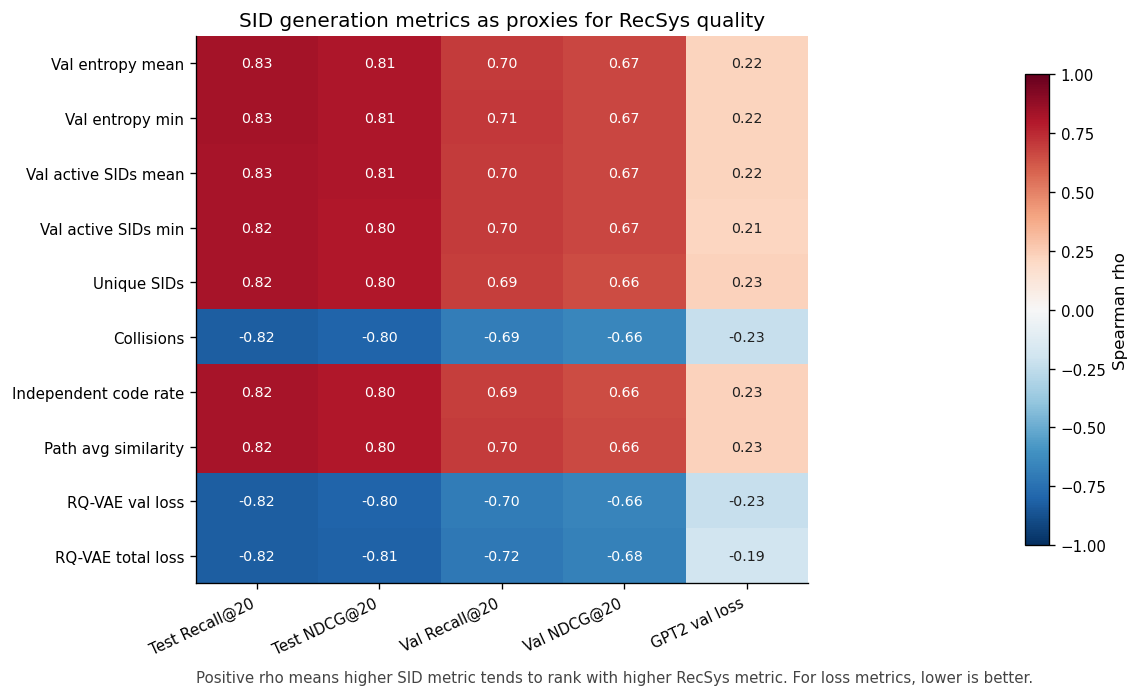

In [20]:
heatmap_sid_metrics = [
    'rq_val_entropy_mean',
    'rq_val_entropy_min',
    'rq_val_sids_num_mean',
    'rq_val_sids_num_min',
    'sid_unique_total',
    'sid_collisions',
    'sid_icr',
    'sid_path_avg_similarity',
    'rqvae_best_val_loss',
    'rqvae_total_loss',
]
heatmap_targets = [
    'test_Recall@20',
    'test_NDCG@20',
    'val_Recall@20',
    'val_NDCG@20',
    'gpt2_best_val_loss',
]

heatmap_data = (
    checkpoint_corr_mean[
        checkpoint_corr_mean['sid_metric'].isin(heatmap_sid_metrics)
        & checkpoint_corr_mean['target_metric'].isin(heatmap_targets)
    ]
    .pivot(index='sid_metric', columns='target_metric', values='spearman_rho')
    .reindex(index=heatmap_sid_metrics, columns=heatmap_targets)
)

fig, ax = plt.subplots(figsize=(9.4, 5.7), constrained_layout=True)
im = ax.imshow(heatmap_data, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')

ax.set_xticks(np.arange(len(heatmap_targets)))
ax.set_xticklabels([metric_labels[m] for m in heatmap_targets], rotation=25, ha='right')
ax.set_yticks(np.arange(len(heatmap_sid_metrics)))
ax.set_yticklabels([metric_labels[m] for m in heatmap_sid_metrics])
ax.set_title('SID generation metrics as proxies for RecSys quality')

for i in range(heatmap_data.shape[0]):
    for j in range(heatmap_data.shape[1]):
        value = heatmap_data.iloc[i, j]
        if pd.isna(value):
            continue
        ax.text(
            j, i, f'{value:.2f}',
            ha='center', va='center',
            color='white' if abs(value) >= 0.55 else '#202020',
            fontsize=8.5,
        )

cbar = fig.colorbar(im, ax=ax, shrink=0.86)
cbar.set_label('Spearman rho')
ax.text(
    0.0, -0.18,
    'Positive rho means higher SID metric tends to rank with higher RecSys metric. For loss metrics, lower is better.',
    transform=ax.transAxes,
    fontsize=9,
    color='#444444',
)

heatmap_path = FIGURES_PATH / 'checkpoint_sid_recsys_corr_heatmap.png'
fig.savefig(heatmap_path, bbox_inches='tight')
saved_report_figures.append(heatmap_path)
plt.show()

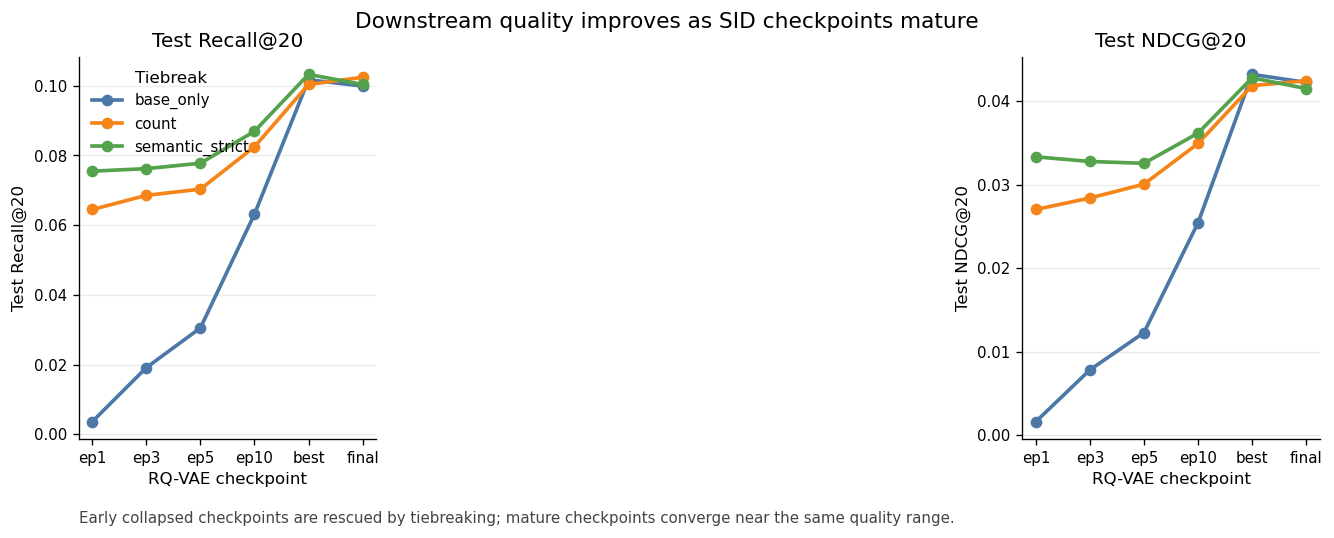

In [21]:
checkpoint_order = ['epoch_001', 'epoch_003', 'epoch_005', 'epoch_010', 'best', 'final']
checkpoint_labels = {
    'epoch_001': 'ep1',
    'epoch_003': 'ep3',
    'epoch_005': 'ep5',
    'epoch_010': 'ep10',
    'best': 'best',
    'final': 'final',
}

quality_by_checkpoint = (
    checkpoint_mean_by_gpt_seed[
        checkpoint_mean_by_gpt_seed['checkpoint_tag'].isin(checkpoint_order)
    ]
    .assign(checkpoint_pos=lambda x: x['checkpoint_tag'].map({tag: i for i, tag in enumerate(checkpoint_order)}))
    .groupby(['tiebreak', 'checkpoint_tag', 'checkpoint_pos'], as_index=False)[
        ['test_Recall@20', 'test_NDCG@20', 'val_Recall@20', 'val_NDCG@20']
    ]
    .mean(numeric_only=True)
    .sort_values(['tiebreak', 'checkpoint_pos'])
)

fig, axes = plt.subplots(1, 2, figsize=(11.0, 4.2), constrained_layout=True)
for ax, target in zip(axes, ['test_Recall@20', 'test_NDCG@20']):
    for tiebreak, tie_df in quality_by_checkpoint.groupby('tiebreak'):
        ax.plot(
            tie_df['checkpoint_pos'],
            tie_df[target],
            marker='o',
            linewidth=2.2,
            markersize=6,
            color=report_palette.get(tiebreak, '#555555'),
            label=tiebreak,
        )
    ax.set_xticks(range(len(checkpoint_order)))
    ax.set_xticklabels([checkpoint_labels[tag] for tag in checkpoint_order])
    ax.set_xlabel('RQ-VAE checkpoint')
    ax.set_ylabel(metric_labels[target])
    ax.set_title(metric_labels[target])
    ax.grid(True, axis='y', alpha=0.25)

axes[0].legend(title='Tiebreak', frameon=False, loc='upper left')
fig.suptitle('Downstream quality improves as SID checkpoints mature', fontsize=13, y=1.03)
axes[0].text(
    0.0, -0.22,
    'Early collapsed checkpoints are rescued by tiebreaking; mature checkpoints converge near the same quality range.',
    transform=axes[0].transAxes,
    fontsize=9,
    color='#444444',
)

line_path = FIGURES_PATH / 'checkpoint_test_quality_by_checkpoint.png'
fig.savefig(line_path, bbox_inches='tight')
saved_report_figures.append(line_path)
plt.show()

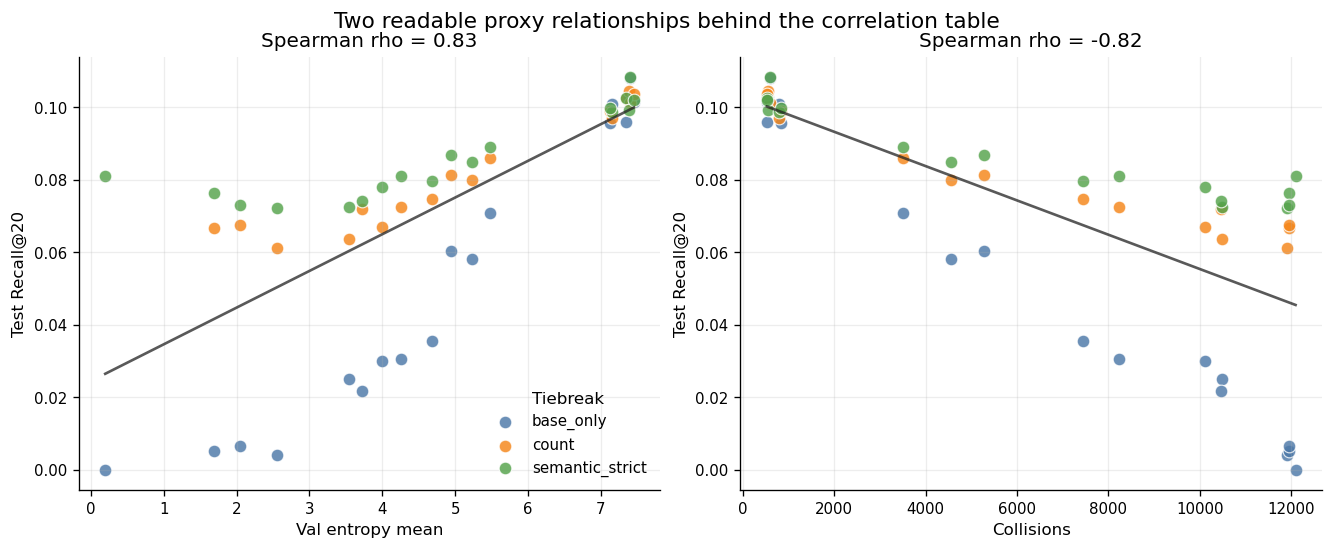

In [22]:
scatter_specs = [
    ('rq_val_entropy_mean', 'test_Recall@20'),
    ('sid_collisions', 'test_Recall@20'),
]

fig, axes = plt.subplots(1, 2, figsize=(11.0, 4.3), constrained_layout=True)
for ax, (x_metric, y_metric) in zip(axes, scatter_specs):
    plot_df = checkpoint_mean_by_gpt_seed[[x_metric, y_metric, 'tiebreak']].dropna()

    for tiebreak, tie_df in plot_df.groupby('tiebreak'):
        ax.scatter(
            tie_df[x_metric],
            tie_df[y_metric],
            s=58,
            alpha=0.82,
            edgecolor='white',
            linewidth=0.7,
            color=report_palette.get(tiebreak, '#555555'),
            label=tiebreak,
        )

    if len(plot_df) >= 3 and plot_df[x_metric].nunique() > 1:
        coef = np.polyfit(plot_df[x_metric], plot_df[y_metric], 1)
        xs = np.linspace(plot_df[x_metric].min(), plot_df[x_metric].max(), 100)
        ax.plot(xs, coef[0] * xs + coef[1], color='#222222', linewidth=1.6, alpha=0.75)

    rho_row = checkpoint_corr_mean[
        checkpoint_corr_mean['sid_metric'].eq(x_metric)
        & checkpoint_corr_mean['target_metric'].eq(y_metric)
    ]
    rho_text = ''
    if len(rho_row):
        rho_text = f"Spearman rho = {rho_row.iloc[0]['spearman_rho']:.2f}"

    ax.set_xlabel(metric_labels[x_metric])
    ax.set_ylabel(metric_labels[y_metric])
    ax.set_title(rho_text)
    ax.grid(True, alpha=0.22)

axes[0].legend(title='Tiebreak', frameon=False, loc='lower right')
fig.suptitle('Two readable proxy relationships behind the correlation table', fontsize=13, y=1.03)

scatter_path = FIGURES_PATH / 'checkpoint_sid_proxy_scatter.png'
fig.savefig(scatter_path, bbox_inches='tight')
saved_report_figures.append(scatter_path)
plt.show()

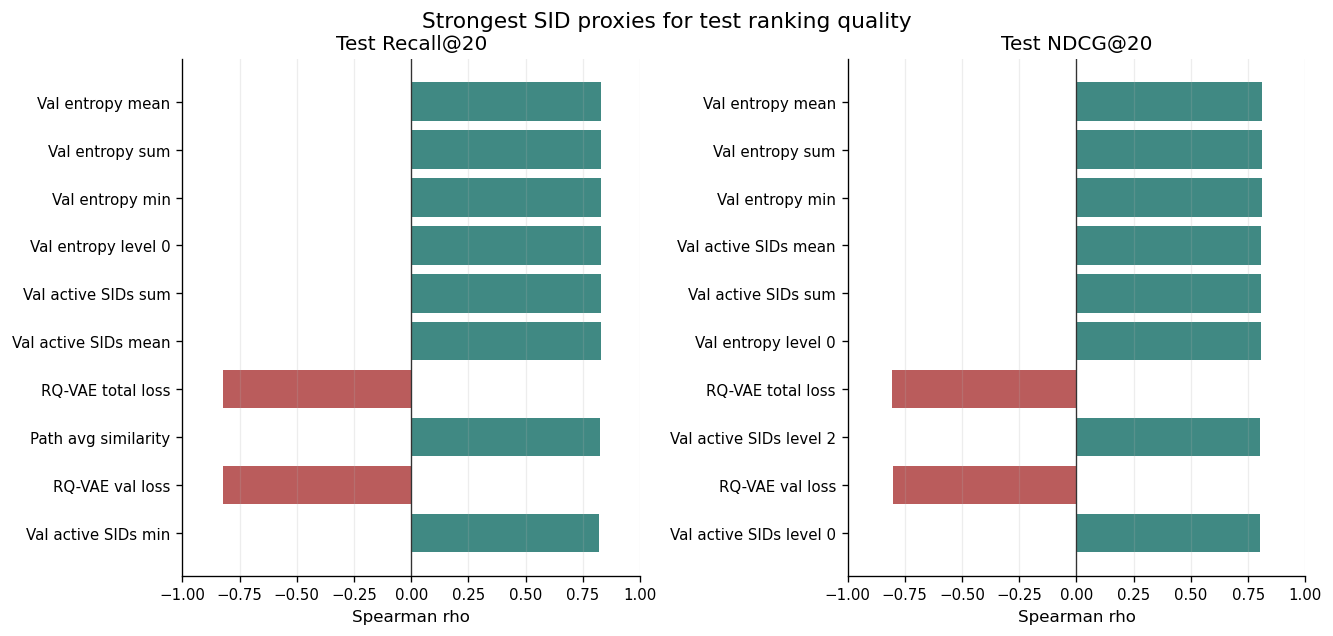

Saved report figures:
c:\Users\Admin\Documents\GitHub\plum_sid_coursework\experiments\figures\checkpoint_sid_recsys_corr_heatmap.png
c:\Users\Admin\Documents\GitHub\plum_sid_coursework\experiments\figures\checkpoint_test_quality_by_checkpoint.png
c:\Users\Admin\Documents\GitHub\plum_sid_coursework\experiments\figures\checkpoint_sid_proxy_scatter.png
c:\Users\Admin\Documents\GitHub\plum_sid_coursework\experiments\figures\checkpoint_sid_proxy_top_bars.png


In [23]:
bar_targets = ['test_Recall@20', 'test_NDCG@20']
fig, axes = plt.subplots(1, 2, figsize=(11.0, 5.0), constrained_layout=True)

for ax, target in zip(axes, bar_targets):
    top = (
        checkpoint_corr_mean[checkpoint_corr_mean['target_metric'].eq(target)]
        .sort_values('abs_spearman', ascending=False)
        .head(10)
        .iloc[::-1]
        .copy()
    )
    colors = ['#2F7F78' if value >= 0 else '#B44E4E' for value in top['spearman_rho']]
    ax.barh(
        [metric_labels.get(m, m) for m in top['sid_metric']],
        top['spearman_rho'],
        color=colors,
        alpha=0.92,
    )
    ax.axvline(0, color='#333333', linewidth=0.8)
    ax.set_xlim(-1, 1)
    ax.set_xlabel('Spearman rho')
    ax.set_title(metric_labels[target])
    ax.grid(True, axis='x', alpha=0.22)

fig.suptitle('Strongest SID proxies for test ranking quality', fontsize=13, y=1.03)

bars_path = FIGURES_PATH / 'checkpoint_sid_proxy_top_bars.png'
fig.savefig(bars_path, bbox_inches='tight')
saved_report_figures.append(bars_path)
plt.show()

print('Saved report figures:')
for path in saved_report_figures:
    print(path)

<!-- /codex-report-figures-v1 -->

### 10. Visual comparison

The plots show the trade-off between ranking metrics and `val_loss_best`.

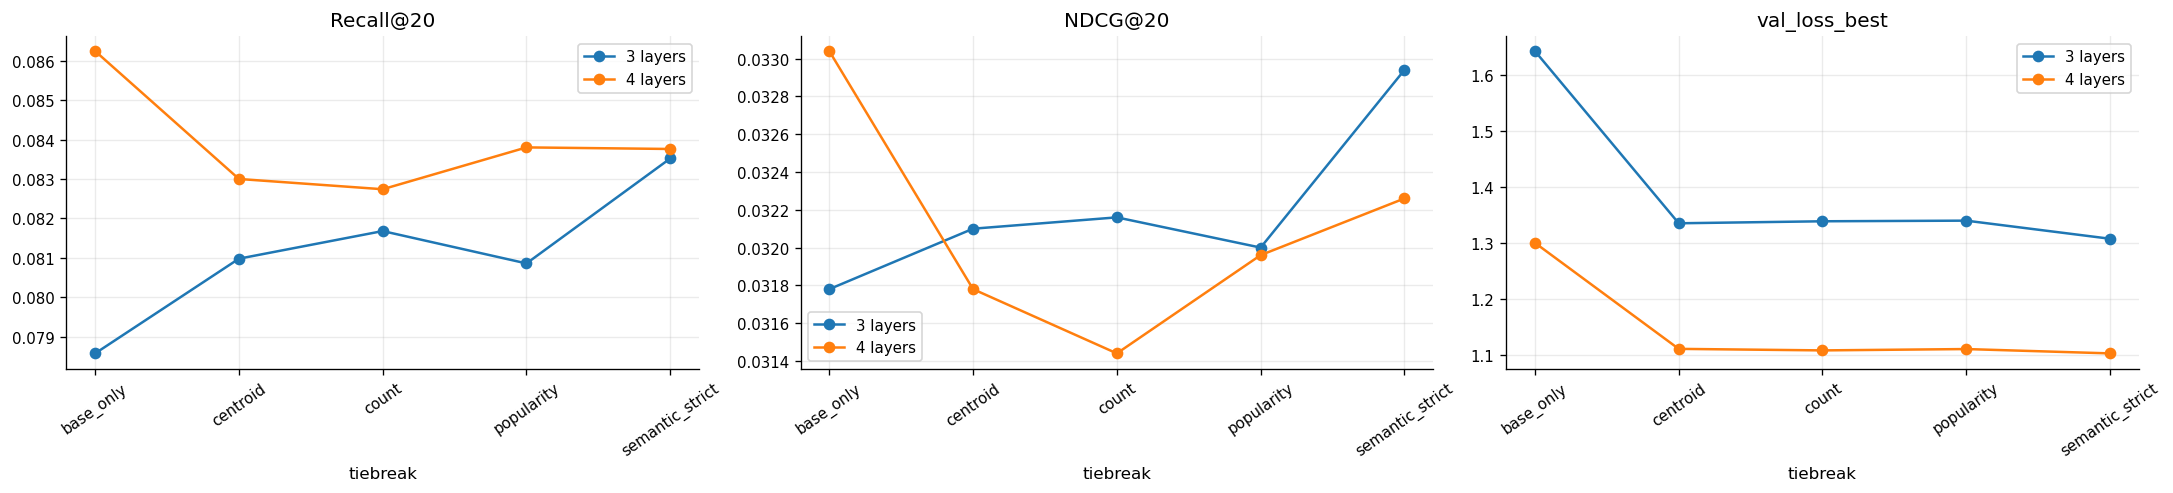

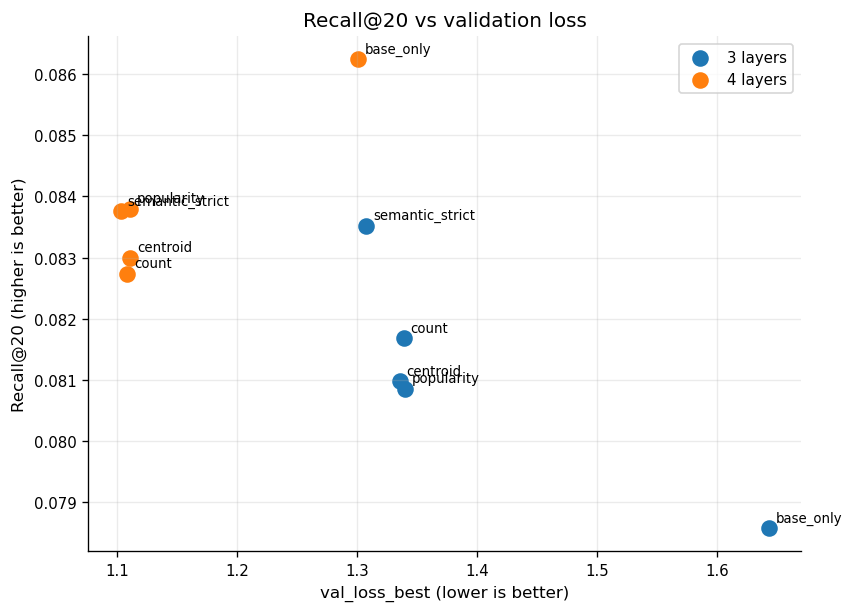

In [24]:
import matplotlib.pyplot as plt

plot_df = mean_scores.reset_index()

fig, axes = plt.subplots(1, 3, figsize=(18, 4), constrained_layout=True)
for ax, metric in zip(axes, ['Recall@20', 'NDCG@20', 'val_loss_best']):
    for n_layers, layer_df in plot_df.groupby('n_layers'):
        ax.plot(layer_df['tiebreak'], layer_df[metric], marker='o', label=f'{n_layers} layers')
    ax.set_title(metric)
    ax.set_xlabel('tiebreak')
    ax.tick_params(axis='x', rotation=35)
    ax.grid(True, alpha=0.25)
    ax.legend()
plt.show()

fig, ax = plt.subplots(figsize=(7, 5), constrained_layout=True)
for n_layers, layer_df in plot_df.groupby('n_layers'):
    ax.scatter(layer_df['val_loss_best'], layer_df['Recall@20'], label=f'{n_layers} layers', s=80)
    for _, row in layer_df.iterrows():
        ax.annotate(row['tiebreak'], (row['val_loss_best'], row['Recall@20']), fontsize=8, xytext=(4, 4), textcoords='offset points')
ax.set_xlabel('val_loss_best (lower is better)')
ax.set_ylabel('Recall@20 (higher is better)')
ax.set_title('Recall@20 vs validation loss')
ax.grid(True, alpha=0.25)
ax.legend()
plt.show()

## Final notes from the added comparisons

1. For `n_layers = 3`, the strongest method on deeper ranking metrics is `semantic_strict`: mean `Recall@20 = 0.08352`, `NDCG@20 = 0.03294`, `val_loss_best = 1.30784`. Compared with `count`, it gives about `+2.25%` Recall@20, `+2.43%` NDCG@20, and about `2.33%` lower validation loss.

2. For `n_layers = 4`, the best method by `Recall@20` and `NDCG@20` is `base_only`: mean `Recall@20 = 0.08624`, `NDCG@20 = 0.03304`. Its validation loss is worse than the tiebreak variants: `1.30052` versus `1.10314` for `semantic_strict`.

3. `val_loss_best` is not always a reliable proxy for downstream ranking quality. With 4 layers, `semantic_strict` has the best validation loss but loses to `base_only` on `Recall@20` and `NDCG@20`.

4. Removing collapsed SIDs does not automatically improve ranking metrics. Tiebreak methods reduce `collapsed` to zero, but with 4 layers `base_only` still has the best `Recall@20` and `NDCG@20` despite `collapsed = 347`.

5. Moving from 3 to 4 layers reduces `val_loss_best` for all tiebreak strategies. For `base_only`, it is especially useful for `Recall@20`: `L4 - L3 = +0.00766`, with 4 layers winning on all 5 seeds.

6. Checkpoint-level correlations suggest that stronger SID generation quality is linked with better downstream ranking quality: higher validation entropy and SID usage, more unique SIDs, fewer collisions, and lower RQ-VAE validation loss track with higher Recall@20 and NDCG@20.

7. The correlation conclusion table saved under `experiments/tables/checkpoint_sid_recsys_correlation_conclusions.csv` summarizes the proxy findings, robustness checks, and caveats.

8. The report-ready figures saved under `experiments/figures` summarize this story as a proxy heatmap, checkpoint progression plot, proxy scatter plot, and top-proxy bar chart.

<!-- /codex-added-comparisons-v2-ascii -->